<a href="https://colab.research.google.com/github/sanimp/A-knowledge-Discovery-Framework-for-High-Dimensional-Youth-Risk-Behavior/blob/main/KDD_Project_Coding_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNOWLEDGE DISCOVERY & DATA MINING PROJECT

# A Knowledge Discovery Framework for High-Dimensional Youth Risk Behavior: From Exploratory Data Analysis to Predictive Modelling

In [1]:
# Importing Libraries
!pip install catboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score)
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
import plotly.express as px
import shap
from google.colab import drive, files
import os
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [2]:
# Loading the Dataset
drive.mount('/content/drive')
file_path = "/content/Alcohol and Other Drug Use.csv.zip"
df = pd.read_csv(file_path, compression='zip')

Mounted at /content/drive


# Initial Exploration

In [3]:
# Checking the data
df.head()

,YEAR,LocationAbbr,LocationDesc,DataSource,Topic,Subtopic,ShortQuestionText,Greater_Risk_Question,Description,Data_Value_Symbol,...,Grade,GeoLocation,TopicId,SubTopicID,QuestionCode,LocationId,StratID1,StratID2,StratID3,StratificationType
0,2005,MM,"Miami-Dade County, FL",YRBSS,Alcohol and Other Drug Use,Other Drug Use,Illegal drugs at school,"Were offered, sold, or given an illegal drug o...",during the 12 months before the survey,%,...,9th,"(25.551603, -80.632692)",C03,C15,H58,108.0,S1,R16,G2,Local
1,2017,SA,"San Diego, CA",YRBSS,Alcohol and Other Drug Use,Alcohol Use,Current binge drinking,Reported current binge drinking,four or more drinks of alcohol in a row (if th...,%,...,Total,"(32.715738, -117.161084)",C03,C14,H44,103.0,S1,R10,G1,Local
2,1995,HO,"Houston, TX",YRBSS,Alcohol and Other Drug Use,Other Drug Use,Ever cocaine use,Ever used cocaine,"any form of cocaine, such as powder, crack, or...",%,...,Total,"(29.760427, -95.369803)",C03,C15,H49,128.0,S7,R13,G1,Local
3,2017,CK,Cherokee Nation,YRBSS,Alcohol and Other Drug Use,Other Drug Use,Ever cocaine use,Ever used cocaine,"any form of cocaine, such as powder, crack, or...",%,...,12th,NaN,C03,C15,H49,NaN,S7,R16,G5,Other
4,2013,WY,Wyoming,YRBSS,Alcohol and Other Drug Use,Alcohol Use,Current alcohol use,Currently drank alcohol,"at least one drink of alcohol, on at least 1 d...",%,...,Total,"(43.23554134300048, -108.10983035299967)",C03,C14,H42,56.0,S7,R12,G1,State


In [4]:
# Finding the data type of the variables
df.dtypes

,0
YEAR,int64
LocationAbbr,object
LocationDesc,object
DataSource,object
Topic,object
Subtopic,object
ShortQuestionText,object
Greater_Risk_Question,object
Description,object
Data_Value_Symbol,object


In [5]:
# Checking the data
df.shape

(1176120, 35)

# Data Quality Assessment

In [6]:
# Check missing values in the dataset
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).values
})
missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)
print("\nMissing Values Summary:")
print(missing_summary.head(20))


Missing Values Summary:
                                     Column  Missing_Count  Missing_Percentage
12  Greater_Risk_Data_Value_Footnote_Symbol        1176120          100.000000
18   Lesser_Risk_Data_Value_Footnote_Symbol        1176120          100.000000
13         Greater_Risk_Data_Value_Footnote        1176120          100.000000
19          Lesser_Risk_Data_Value_Footnote        1176120          100.000000
20         Lesser_Risk_Low_Confidence_Limit         822598           69.941673
14        Greater_Risk_Low_Confidence_Limit         822598           69.941673
21        Lesser_Risk_High_Confidence_Limit         822598           69.941673
15       Greater_Risk_High_Confidence_Limit         822598           69.941673
17                   Lesser_Risk_Data_Value         822598           69.941673
11                  Greater_Risk_Data_Value         822598           69.941673
26                              GeoLocation          46560            3.958780
30                         

In [7]:
# Checking for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


# Descriptive Statistics and Distributions
Descriptive data analysis is the simplest form of data analysis, focusing on 'what happened in the past'. It focuses on summarizing and describing data. It helps us understand the basic characteristics of our dataset.

## Common Metrics:

* Mean, median, mode;
* Standard deviation, variance;
* Minimum, maximum, range;
* Percentiles; etc.

In [8]:
# Finding the descriptive statistics of the data
df.describe()

,YEAR,Greater_Risk_Data_Value,Greater_Risk_Data_Value_Footnote_Symbol,Greater_Risk_Data_Value_Footnote,Greater_Risk_Low_Confidence_Limit,Greater_Risk_High_Confidence_Limit,Lesser_Risk_Data_Value,Lesser_Risk_Data_Value_Footnote_Symbol,Lesser_Risk_Data_Value_Footnote,Lesser_Risk_Low_Confidence_Limit,Lesser_Risk_High_Confidence_Limit,LocationId
count,1.176120e+06,353522.000000,0.0,0.0,353522.000000,353522.000000,353522.000000,0.0,0.0,353522.000000,353522.000000,1.164000e+06
mean,2.007435e+03,18.761156,NaN,NaN,14.754483,24.233590,81.238844,NaN,NaN,75.766410,85.245517,6.558495e+01
std,6.885178e+00,19.030676,NaN,NaN,17.163876,20.384117,19.030676,NaN,NaN,20.384117,17.163876,4.859695e+01
min,1.991000e+03,0.000000,NaN,NaN,0.000000,0.000000,2.967100,NaN,NaN,0.550600,6.319100,1.000000e+00
25%,2.003000e+03,4.293325,NaN,NaN,2.239100,8.274800,71.992625,NaN,NaN,64.653900,78.045900,2.600000e+01
50%,2.009000e+03,11.353150,NaN,NaN,7.535100,17.364850,88.646850,NaN,NaN,82.635150,92.464900,4.900000e+01
75%,2.013000e+03,28.007375,NaN,NaN,21.954100,35.346100,95.706675,NaN,NaN,91.725200,97.760900,1.100000e+02
max,2.017000e+03,97.032900,NaN,NaN,93.680900,99.449400,100.000000,NaN,NaN,100.000000,100.000000,2.040000e+02


In [9]:
# Dropping variables with missing percentage = 100
fully_missing = missing_summary[missing_summary['Missing_Percentage'] == 100]['Column'].tolist()
df = df.drop(columns=fully_missing)

In [10]:
df.head()


,YEAR,LocationAbbr,LocationDesc,DataSource,Topic,Subtopic,ShortQuestionText,Greater_Risk_Question,Description,Data_Value_Symbol,...,Grade,GeoLocation,TopicId,SubTopicID,QuestionCode,LocationId,StratID1,StratID2,StratID3,StratificationType
0,2005,MM,"Miami-Dade County, FL",YRBSS,Alcohol and Other Drug Use,Other Drug Use,Illegal drugs at school,"Were offered, sold, or given an illegal drug o...",during the 12 months before the survey,%,...,9th,"(25.551603, -80.632692)",C03,C15,H58,108.0,S1,R16,G2,Local
1,2017,SA,"San Diego, CA",YRBSS,Alcohol and Other Drug Use,Alcohol Use,Current binge drinking,Reported current binge drinking,four or more drinks of alcohol in a row (if th...,%,...,Total,"(32.715738, -117.161084)",C03,C14,H44,103.0,S1,R10,G1,Local
2,1995,HO,"Houston, TX",YRBSS,Alcohol and Other Drug Use,Other Drug Use,Ever cocaine use,Ever used cocaine,"any form of cocaine, such as powder, crack, or...",%,...,Total,"(29.760427, -95.369803)",C03,C15,H49,128.0,S7,R13,G1,Local
3,2017,CK,Cherokee Nation,YRBSS,Alcohol and Other Drug Use,Other Drug Use,Ever cocaine use,Ever used cocaine,"any form of cocaine, such as powder, crack, or...",%,...,12th,NaN,C03,C15,H49,NaN,S7,R16,G5,Other
4,2013,WY,Wyoming,YRBSS,Alcohol and Other Drug Use,Alcohol Use,Current alcohol use,Currently drank alcohol,"at least one drink of alcohol, on at least 1 d...",%,...,Total,"(43.23554134300048, -108.10983035299967)",C03,C14,H42,56.0,S7,R12,G1,State


Plotting distributions for columns: ['YEAR', 'Topic', 'Sex', 'Grade', 'Greater_Risk_Data_Value']


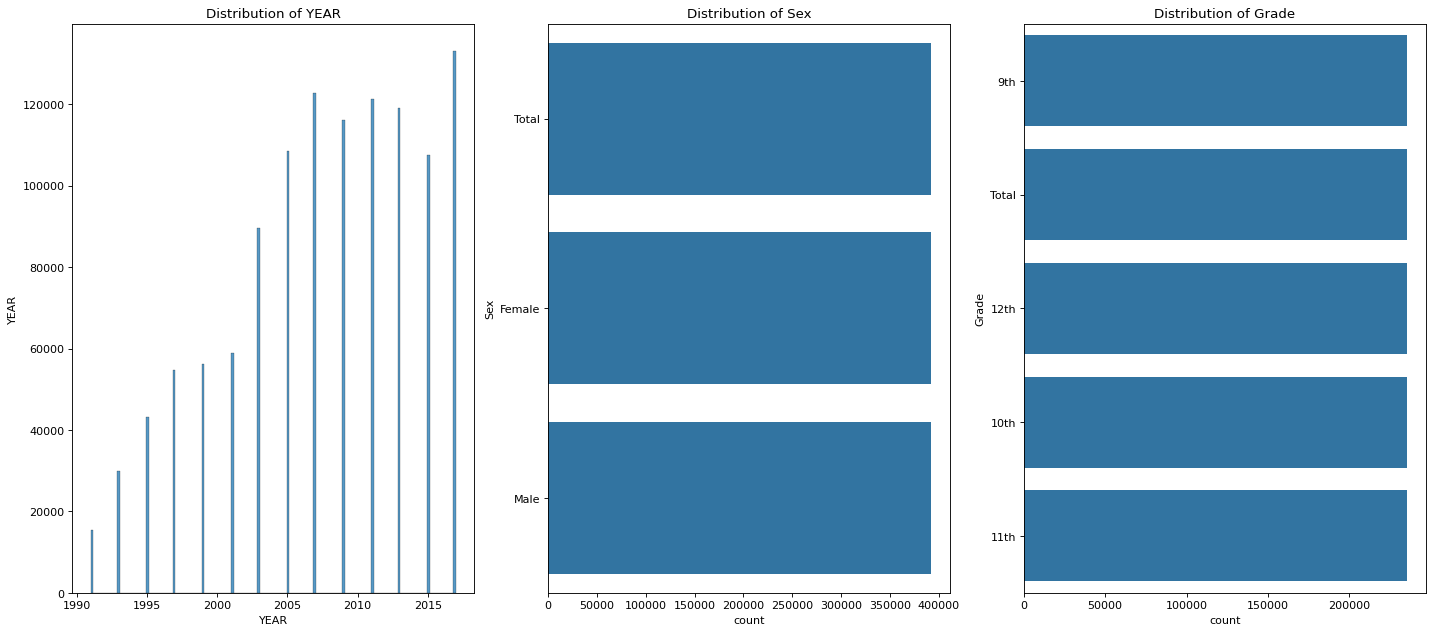

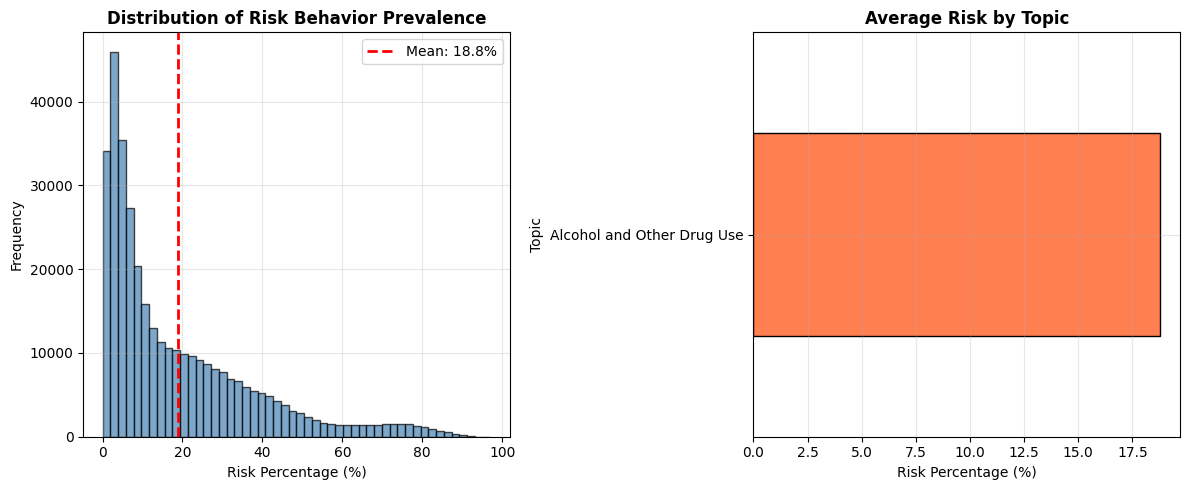

In [11]:
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]].copy() # For displaying purposes, drop columns that have too many unique values or only one value
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDt = df.iloc[:, i].dropna()
        if (columnDt.dtype == 'int64' or columnDt.dtype == 'float64'):
            sns.histplot(columnDt, kde=False)
        else:
            sns.countplot(y=columnDt, order=columnDt.value_counts().index)
        plt.ylabel(columnNames[i])
        plt.title(f'Distribution of {columnNames[i]}')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

# Select columns for distribution plots
columns_for_plots = ['YEAR', 'Topic', 'Sex', 'Grade', 'Greater_Risk_Data_Value']
available_cols = [col for col in columns_for_plots if col in df.columns]

# Create a subset for distribution analysis
if len(available_cols) > 0:
    df_dist = df[available_cols].copy()
    print(f"Plotting distributions for columns: {available_cols}")
    plotPerColumnDistribution(df_dist, nGraphShown=10, nGraphPerRow=3)
else:
    print("No suitable columns found for distribution plots")

# Additional distribution plots
plt.figure(figsize=(12, 5))

# Plot 1: Distribution of risk percentages
plt.subplot(1, 2, 1)
if 'Greater_Risk_Data_Value' in df.columns:
    plt.hist(df['Greater_Risk_Data_Value'].dropna(), bins=50,
             color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(df['Greater_Risk_Data_Value'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Mean: {df["Greater_Risk_Data_Value"].mean():.1f}%')
    plt.xlabel('Risk Percentage (%)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Risk Behavior Prevalence', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 2: Risk by Topic
plt.subplot(1, 2, 2)
if 'Topic' in df.columns and 'Greater_Risk_Data_Value' in df.columns:
    top_topics = df['Topic'].value_counts().head(8).index
    topic_data = df[df['Topic'].isin(top_topics)]
    topic_means = topic_data.groupby('Topic')['Greater_Risk_Data_Value'].mean().sort_values()
    topic_means.plot(kind='barh', color='coral', edgecolor='black')
    plt.xlabel('Risk Percentage (%)')
    plt.title('Average Risk by Topic', fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Converting categorical variables to factors
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = df[col].astype('category')

print("Data types after converting categorical variables to factors:")
df.dtypes

Data types after converting categorical variables to factors:


,0
YEAR,int64
LocationAbbr,category
LocationDesc,category
DataSource,category
Topic,category
Subtopic,category
ShortQuestionText,category
Greater_Risk_Question,category
Description,category
Data_Value_Symbol,category


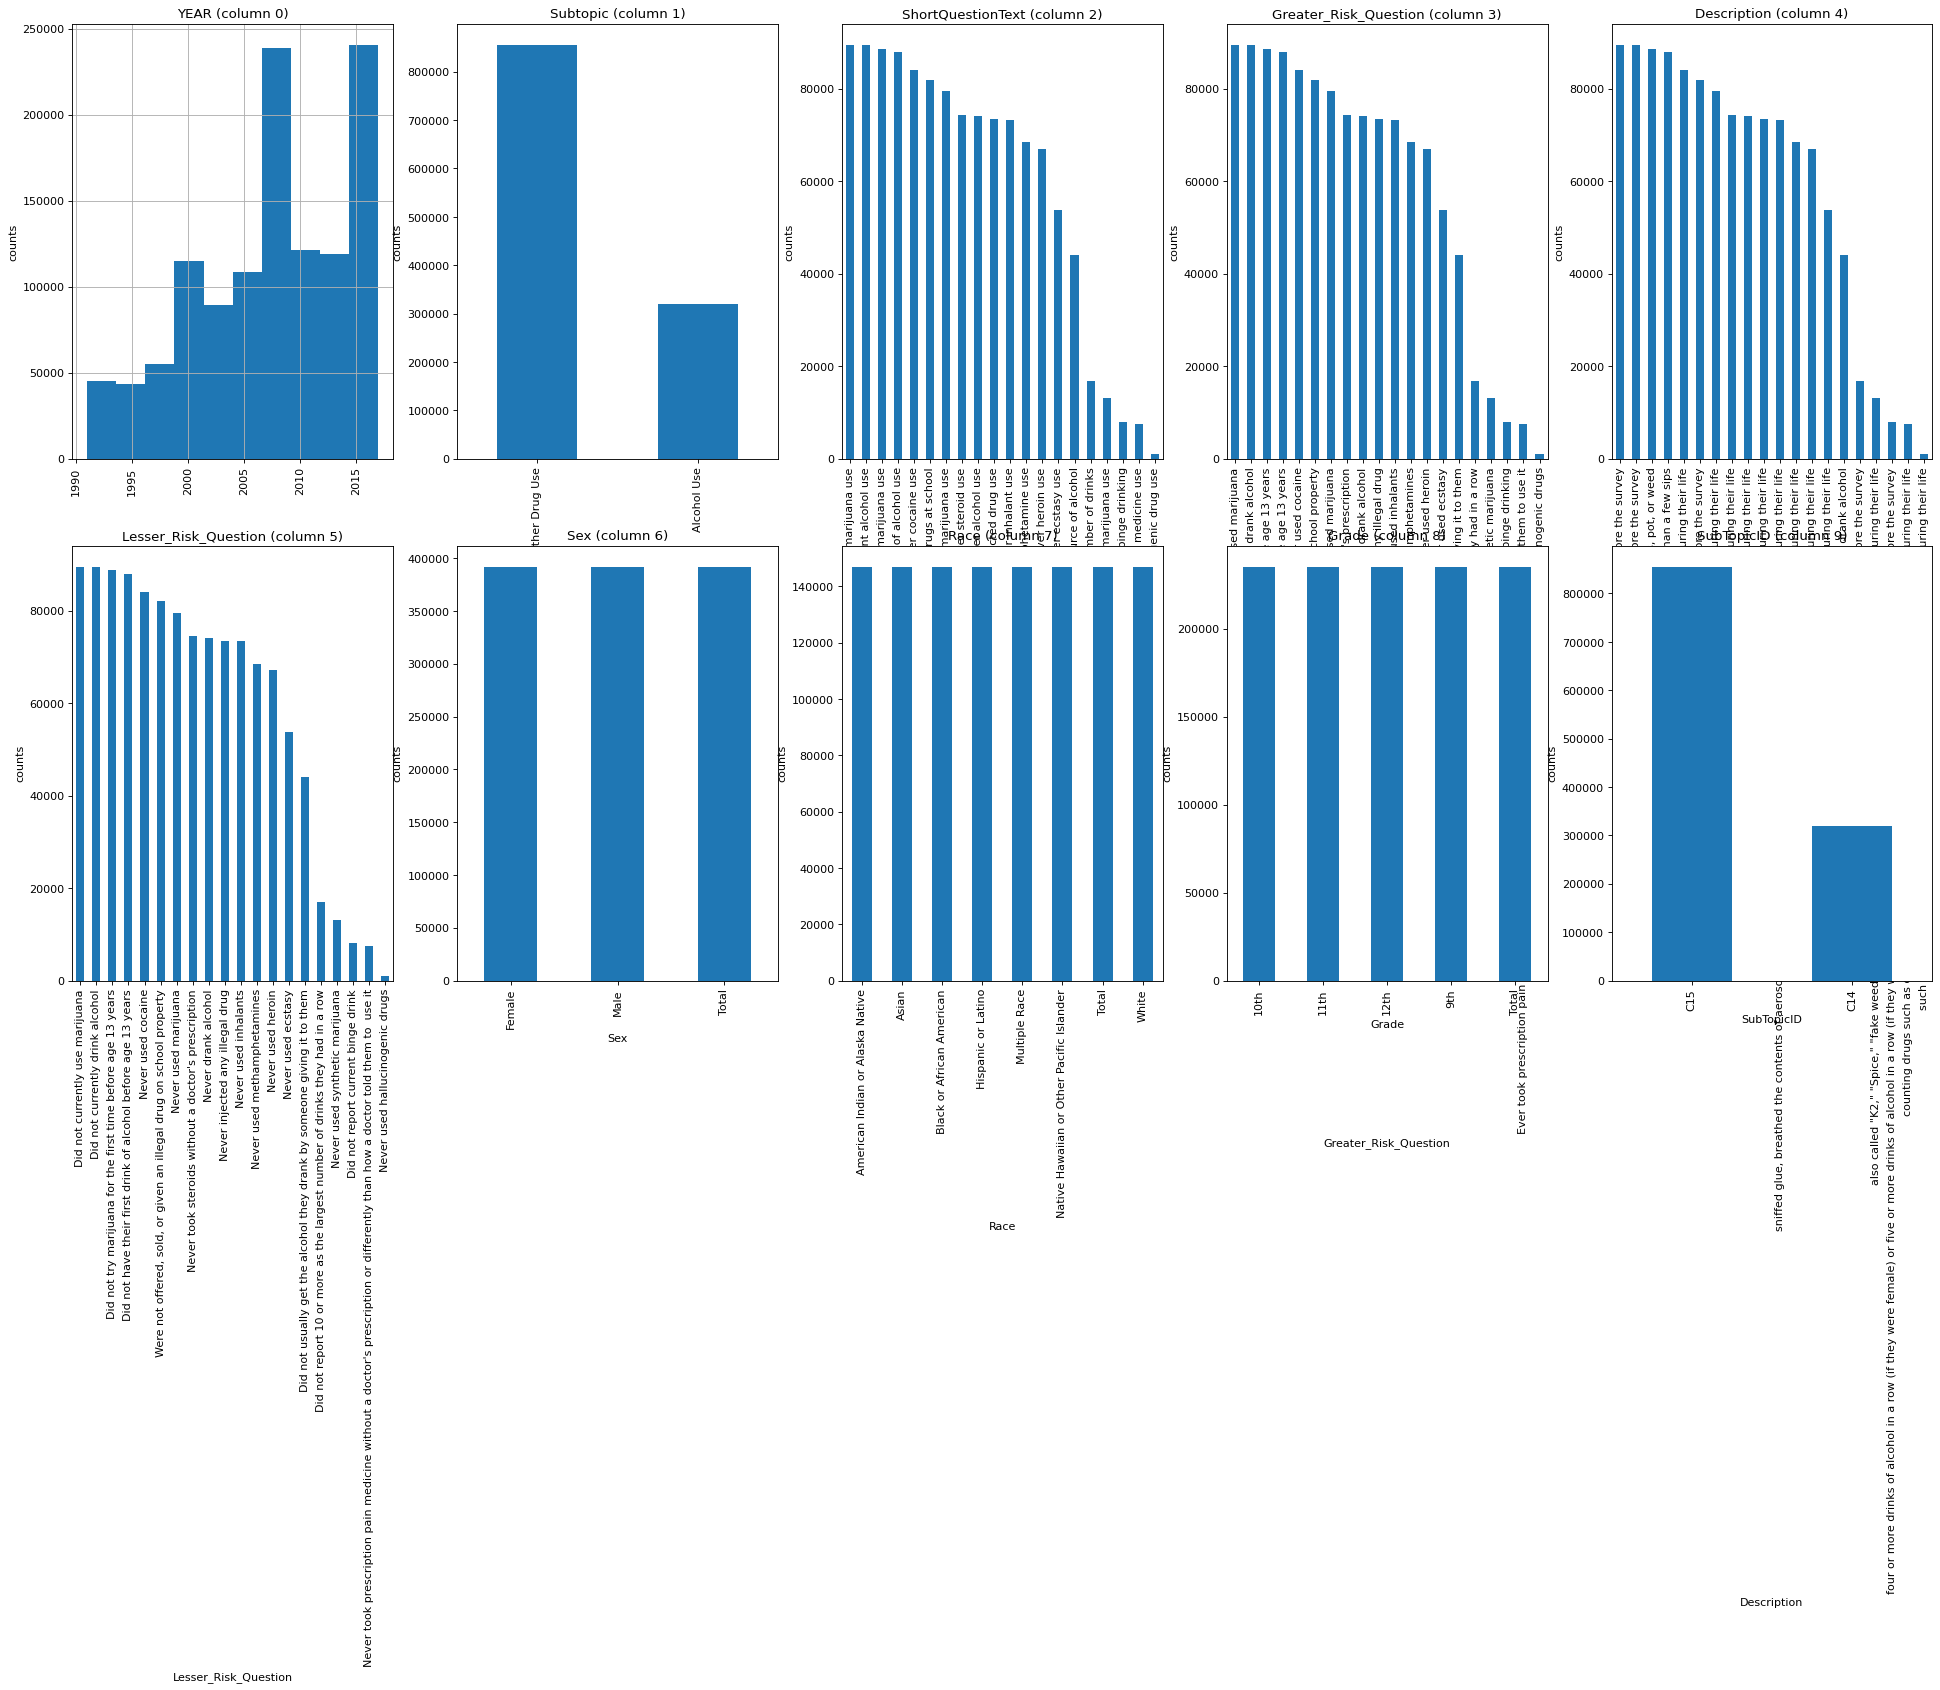

In [13]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.savefig('column_distributions.png', dpi=300, bbox_inches='tight')  # ← ADD THIS
    plt.show()

plotPerColumnDistribution(df, 10, 5)

# Research Questions


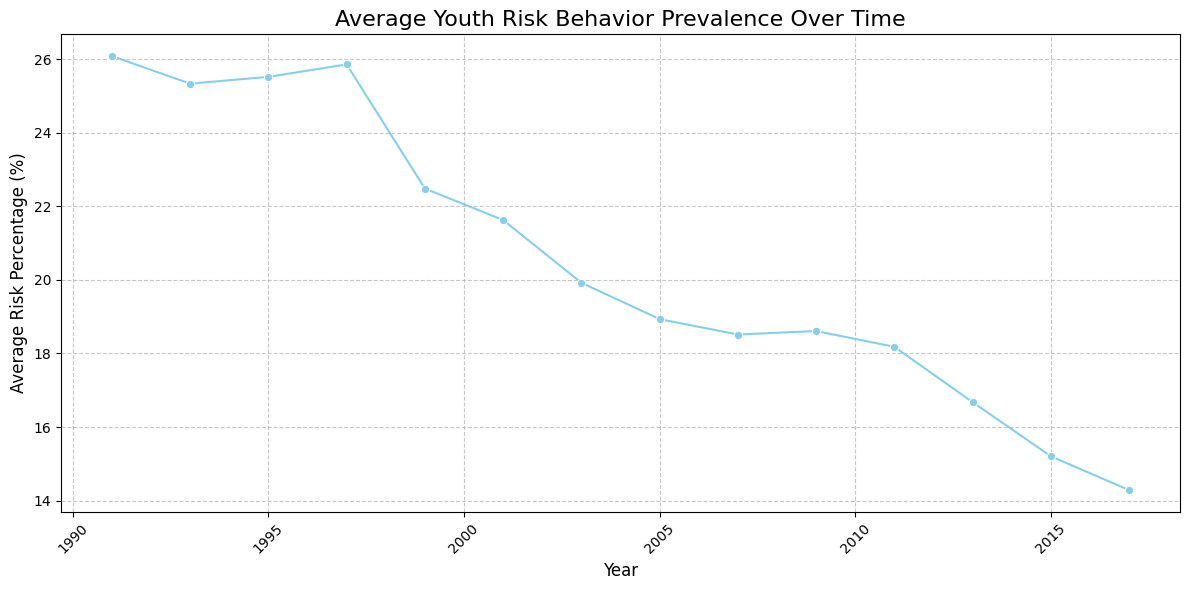

In [14]:
# How have youth risk behaviours changed over time
# Calculate the average Greater_Risk_Data_Value per year
risk_over_time = df.groupby('YEAR')['Greater_Risk_Data_Value'].mean().reset_index()

# Plotting the trend of risk behaviors over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='Greater_Risk_Data_Value', data=risk_over_time, marker='o', color='skyblue')
plt.title('Average Youth Risk Behavior Prevalence Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Risk Percentage (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Which state consistently exhibit higher risk behaviour levels

# Calculate the average Greater_Risk_Data_Value for each location
location_risk = df.groupby('LocationDesc')['Greater_Risk_Data_Value'].mean().reset_index()

# Sort in descending order to find locations with higher risk levels
location_risk_sorted = location_risk.sort_values(by='Greater_Risk_Data_Value', ascending=False)

# Display the top 10 locations with the highest average risk behaviors
print("Top 10 Locations with Highest Average Risk Behavior Prevalence:")
display(location_risk_sorted.head(10))


Top 10 Locations with Highest Average Risk Behavior Prevalence:


,LocationDesc,Greater_Risk_Data_Value
23,"Denver, CO",33.009244
17,"Cleveland, OH",26.949934
69,Palau,24.731696
52,Navajo,24.049076
20,"Dallas, TX",23.771113
54,Nevada,23.334707
48,"Milwaukee, WI",22.943260
44,Massachusetts,22.380165
78,"Seattle, WA",22.049761
81,South Dakota,21.879226


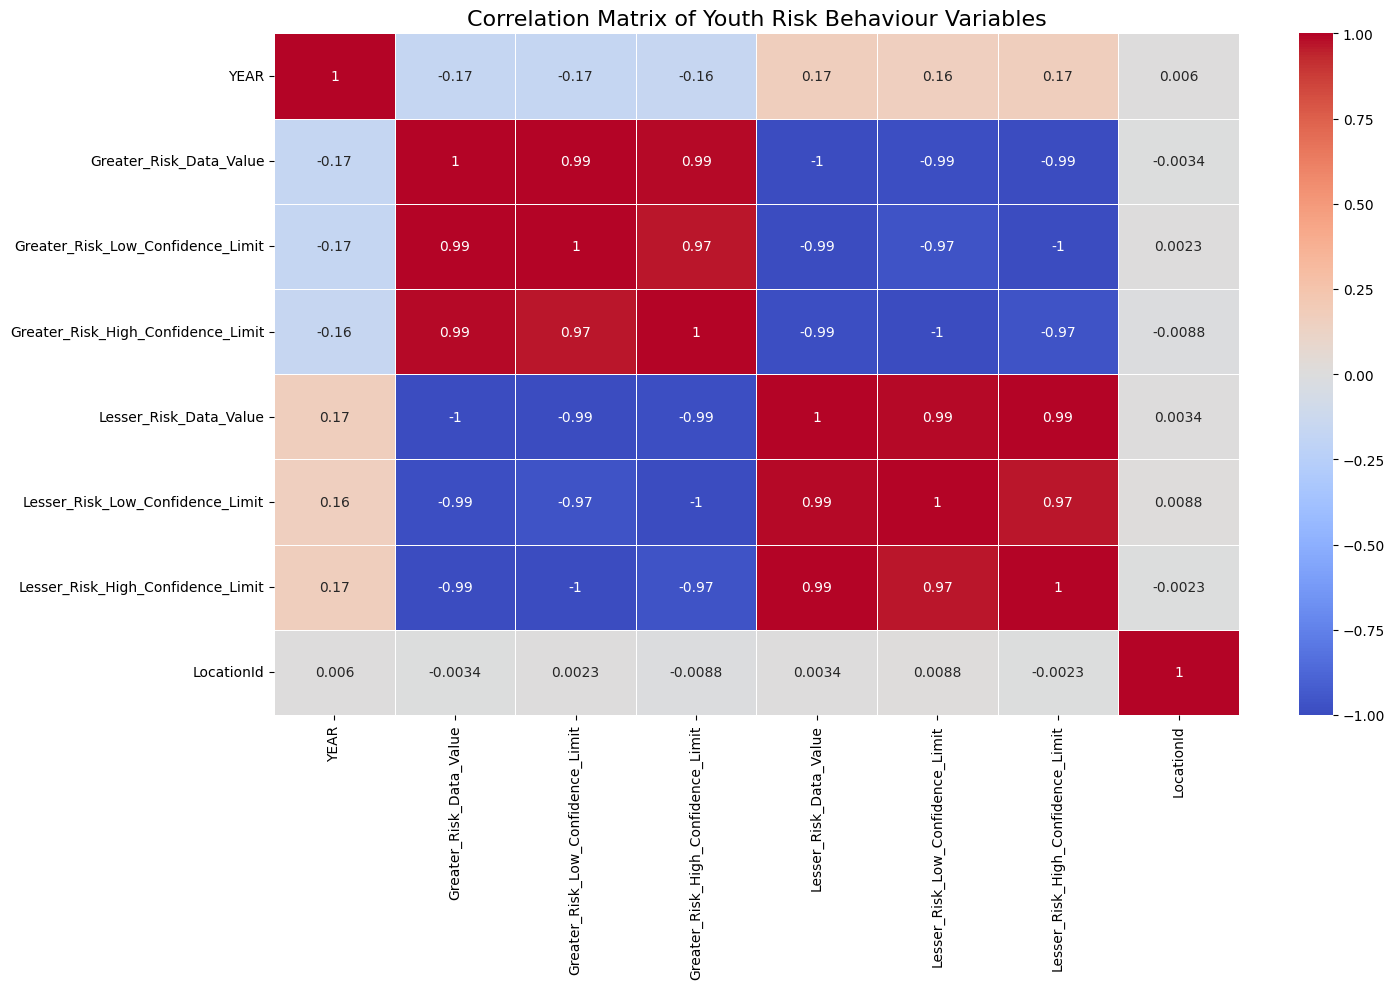

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Check the correlation between the variables
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Youth Risk Behaviour Variables', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')  # save first
plt.show()

files.download('correlation_heatmap.png')  # triggers browser download

## Confidence Interval Analysis


Risk Behavior by Sex:
   Sex      mean       std  count
Female 17.392234 19.259586 108392
  Male 19.992546 18.867151 103562
 Total 18.908470 18.905782 141568


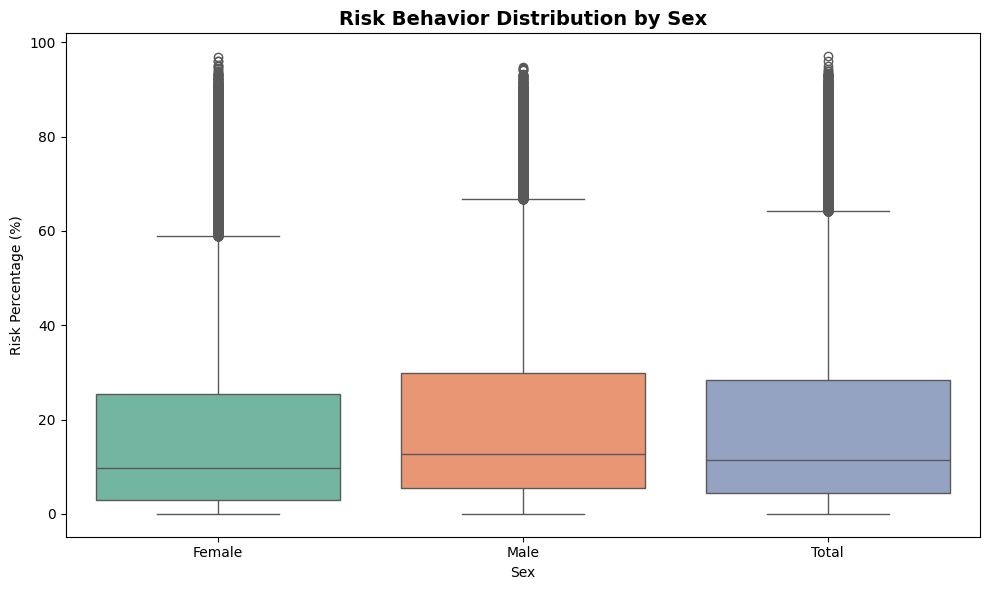


Risk Behavior by Grade:
Grade      mean       std  count
 10th 18.258691 18.525975  64999
 11th 19.258902 19.951887  61606
 12th 20.394850 21.341038  55708
  9th 16.851626 16.804725  66390
Total 19.121390 18.698125 104819


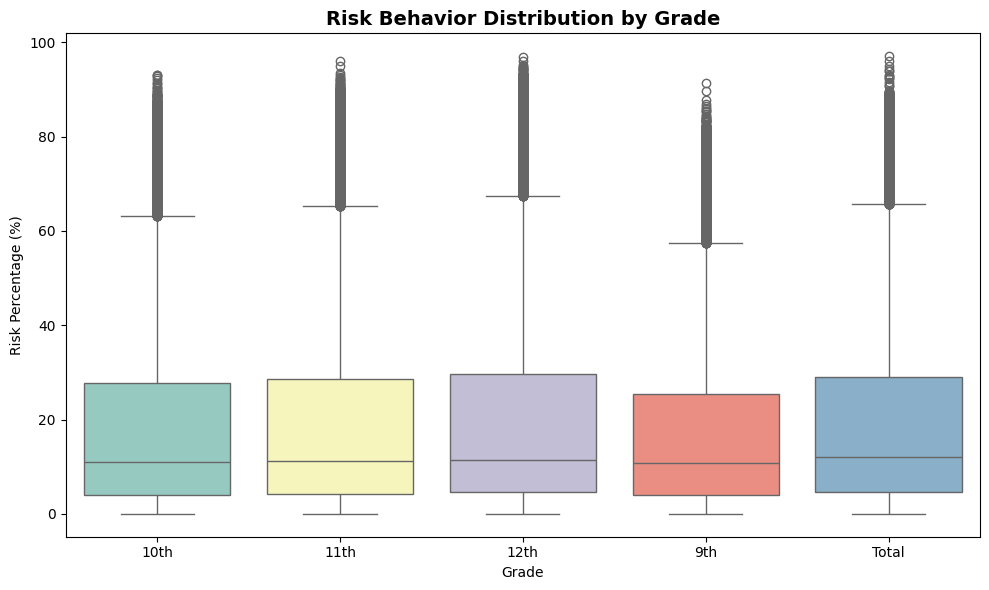

In [17]:
# Analyze by sex
if 'Sex' in df.columns:
    sex_analysis = df.groupby('Sex')['Greater_Risk_Data_Value'].agg(['mean', 'std', 'count']).reset_index()
    print("\nRisk Behavior by Sex:")
    print(sex_analysis.to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Sex', y='Greater_Risk_Data_Value', palette='Set2')
    plt.title('Risk Behavior Distribution by Sex', fontsize=14, fontweight='bold')
    plt.xlabel('Sex')
    plt.ylabel('Risk Percentage (%)')
    plt.tight_layout()
    plt.savefig('sex_analysis.png', dpi=300)
    plt.show()

# Analyze by grade
if 'Grade' in df.columns:
    grade_analysis = df.groupby('Grade')['Greater_Risk_Data_Value'].agg(['mean', 'std', 'count']).reset_index()
    print("\nRisk Behavior by Grade:")
    print(grade_analysis.to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Grade', y='Greater_Risk_Data_Value', palette='Set3')
    plt.title('Risk Behavior Distribution by Grade', fontsize=14, fontweight='bold')
    plt.xlabel('Grade')
    plt.ylabel('Risk Percentage (%)')
    plt.tight_layout()
    plt.savefig('grade_analysis.png', dpi=300)
    plt.show()

In [18]:
# Calculating Confidence Intervals for All Groups

def calculate_confidence_interval(mean, std, count, confidence_level=0.95):
    """Calculates the confidence interval for a mean."""
    if count < 2:
        return float('nan'), float('nan')
    alpha = 1 - confidence_level
    z_score = stats.norm.ppf(1 - alpha / 2)
    standard_error = std / np.sqrt(count)
    margin_of_error = z_score * standard_error
    return mean - margin_of_error, mean + margin_of_error

# Confidence Intervals for Sex
print("\n--- Confidence Intervals for Risk Behavior by Sex ---")
sex_analysis['lower_ci'], sex_analysis['upper_ci'] = zip(*sex_analysis.apply(
    lambda row: calculate_confidence_interval(row['mean'], row['std'], row['count']), axis=1
))
display(sex_analysis)

# Confidence Intervals for Grade (guarded)
if 'grade_analysis' in dir():
    print("\n--- Confidence Intervals for Risk Behavior by Grade ---")
    grade_analysis['lower_ci'], grade_analysis['upper_ci'] = zip(*grade_analysis.apply(
        lambda row: calculate_confidence_interval(row['mean'], row['std'], row['count']), axis=1
    ))
    display(grade_analysis)
else:
    print("Grade analysis not available — Grade column may be absent in this dataset.")


--- Confidence Intervals for Risk Behavior by Sex ---


,Sex,mean,std,count,lower_ci,upper_ci
0,Female,17.392234,19.259586,108392,17.277578,17.506890
1,Male,19.992546,18.867151,103562,19.877637,20.107455
2,Total,18.908470,18.905782,141568,18.809988,19.006953



--- Confidence Intervals for Risk Behavior by Grade ---


,Grade,mean,std,count,lower_ci,upper_ci
0,10th,18.258691,18.525975,64999,18.116270,18.401113
1,11th,19.258902,19.951887,61606,19.101351,19.416453
2,12th,20.394850,21.341038,55708,20.217633,20.572067
3,9th,16.851626,16.804725,66390,16.723797,16.979454
4,Total,19.121390,18.698125,104819,19.008196,19.234585


### Interpretation of Confidence Intervals

**Risk Behavior by Sex:**

From the confidence intervals for 'Female' and 'Male' groups, we can observe whether their intervals overlap. If they do not overlap, it suggests a statistically significant difference in mean risk behavior between the sexes at the 95% confidence level.

**Risk Behavior by Grade:**

Similarly, by examining the confidence intervals for each 'Grade' level, we can determine if there are statistically meaningful differences in mean risk behavior across different grades. Non-overlapping confidence intervals between grades would indicate a statistically significant difference.

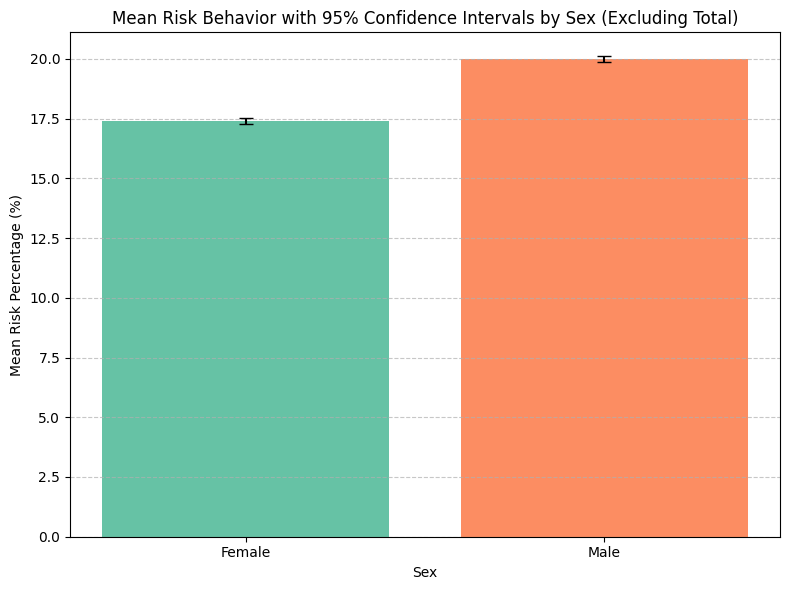

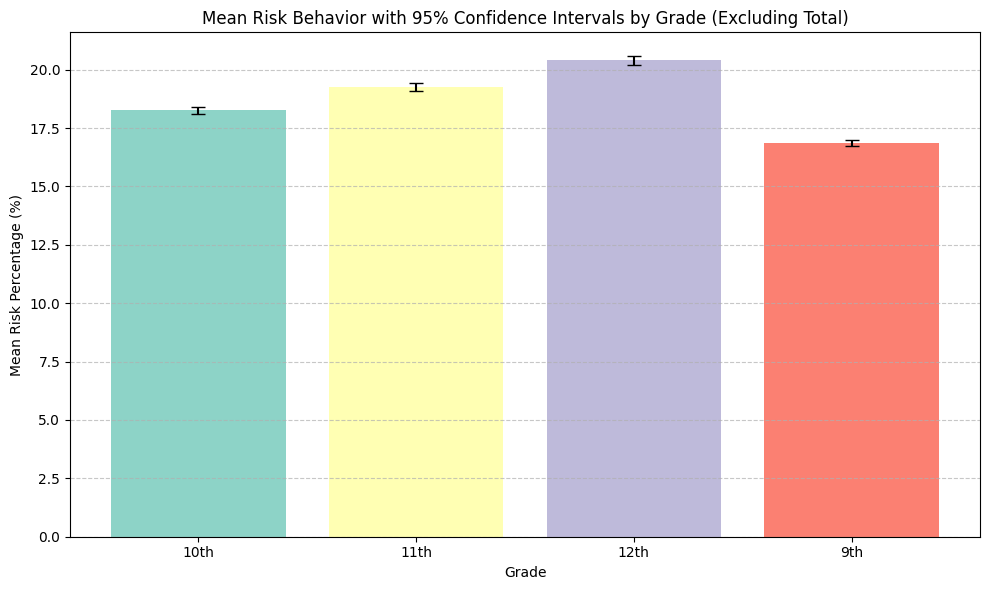

In [19]:
# Visualize Confidence Intervals for Sex
sex_analysis_filtered = sex_analysis[sex_analysis['Sex'].isin(['Female', 'Male'])]
plt.figure(figsize=(8, 6))

# Prepare error data for matplotlib
lower_err_sex = sex_analysis_filtered['mean'] - sex_analysis_filtered['lower_ci']
upper_err_sex = sex_analysis_filtered['upper_ci'] - sex_analysis_filtered['mean']
yerr_values_sex = np.array([lower_err_sex, upper_err_sex])

# Use plt.bar directly for better control with pre-calculated errors
plt.bar(
    x=sex_analysis_filtered['Sex'],
    height=sex_analysis_filtered['mean'],
    yerr=yerr_values_sex,
    capsize=5, # Capsize for matplotlib is in points
    color=sns.color_palette("Set2", len(sex_analysis_filtered)) # Match seaborn palette
)
plt.title('Mean Risk Behavior with 95% Confidence Intervals by Sex (Excluding Total)')
plt.ylabel('Mean Risk Percentage (%)')
plt.xlabel('Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize Confidence Intervals for Grade
grade_analysis_filtered = grade_analysis[grade_analysis['Grade'] != 'Total']
plt.figure(figsize=(10, 6))

# Prepare error data for matplotlib
lower_err_grade = grade_analysis_filtered['mean'] - grade_analysis_filtered['lower_ci']
upper_err_grade = grade_analysis_filtered['upper_ci'] - grade_analysis_filtered['mean']
yerr_values_grade = np.array([lower_err_grade, upper_err_grade])

# Use plt.bar directly for better control with pre-calculated errors
plt.bar(
    x=grade_analysis_filtered['Grade'],
    height=grade_analysis_filtered['mean'],
    yerr=yerr_values_grade,
    capsize=5, # Capsize for matplotlib is in points
    color=sns.color_palette("Set3", len(grade_analysis_filtered)) # Match seaborn palette
)
plt.title('Mean Risk Behavior with 95% Confidence Intervals by Grade (Excluding Total)')
plt.ylabel('Mean Risk Percentage (%)')
plt.xlabel('Grade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
# PREPARE DATA FOR GEOGRAPHIC ANALYSIS

# Check if LocationAbbr column exists
if 'LocationAbbr' not in df.columns:
    print("ERROR: 'LocationAbbr' column not found. Available columns:")
    print(df.columns.tolist())
else:
    # Calculate state-level averages
    state_risk = df.groupby('LocationAbbr').agg({
        'Greater_Risk_Data_Value': 'mean'
    }).reset_index()
    state_risk.columns = ['State_Code', 'Risk_Percentage']

    # Add state names
    state_names = {
        'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
        'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
        'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
        'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
        'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
        'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
        'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
        'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
        'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
        'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
        'DC': 'District of Columbia'
    }

    state_risk['State'] = state_risk['State_Code'].map(state_names)
    state_risk = state_risk.dropna(subset=['State'])  # Remove any states not in mapping

    print(f"Data prepared for {len(state_risk)} states")
    print("\nSample data:")
    print(state_risk.head(10))

Data prepared for 46 states

Sample data:
   State_Code  Risk_Percentage        State
0          AK        19.133744       Alaska
1          AL        20.622934      Alabama
2          AR        20.678565     Arkansas
7          CA        15.172141   California
12         CO        18.516792     Colorado
13         CT        16.425361  Connecticut
16         DE        19.290462     Delaware
21         FL        18.780067      Florida
24         GA        20.416467      Georgia
26         HI        16.353253       Hawaii


In [21]:
try:
    # Create interactive choropleth map
    fig = px.choropleth(
        state_risk,
        locations='State_Code',
        locationmode='USA-states',
        color='Risk_Percentage',
        scope='usa',
        color_continuous_scale='RdYlGn_r',  # Red = high risk, Green = low risk
        range_color=[state_risk['Risk_Percentage'].min(),
                     state_risk['Risk_Percentage'].max()],
        hover_name='State',
        hover_data={
            'Risk_Percentage': ':.1f',
            'State_Code': False
        },
        title='<b>Youth Risk Behavior Prevalence by State</b><br><sup>Higher percentage indicates greater risk behavior prevalence</sup>',
        labels={'Risk_Percentage': 'Risk Prevalence (%)'}
    )

    # Update layout for better appearance
    fig.update_layout(
        title_x=0.5,
        title_font_size=16,
        geo=dict(
            bgcolor='lightgray',
            lakecolor='lightblue',
            landcolor='white',
            subunitcolor='gray',
            countrycolor='gray'
        ),
        width=1000,
        height=600,
        coloraxis_colorbar=dict(
            title="Risk %",
            thickness=20,
            len=0.7,
            tickformat='.0f'
        )
    )

    # Display the map
    fig.show()

    # Save as HTML
    fig.write_html("usa_risk_map_plotly.html")
    print("Map saved as 'usa_risk_map_plotly.html'")

except Exception as e:
    print(f"Error creating Plotly map: {e}")
    print("Trying alternative method...")

    # Alternative: Simple bar chart if map fails
    plt.figure(figsize=(12, 10))
    state_risk_sorted = state_risk.sort_values('Risk_Percentage', ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(state_risk_sorted)))
    plt.barh(state_risk_sorted['State'], state_risk_sorted['Risk_Percentage'], color=colors)
    plt.xlabel('Risk Percentage (%)', fontsize=12)
    plt.title('Risk Behavior Prevalence by State', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

Map saved as 'usa_risk_map_plotly.html'


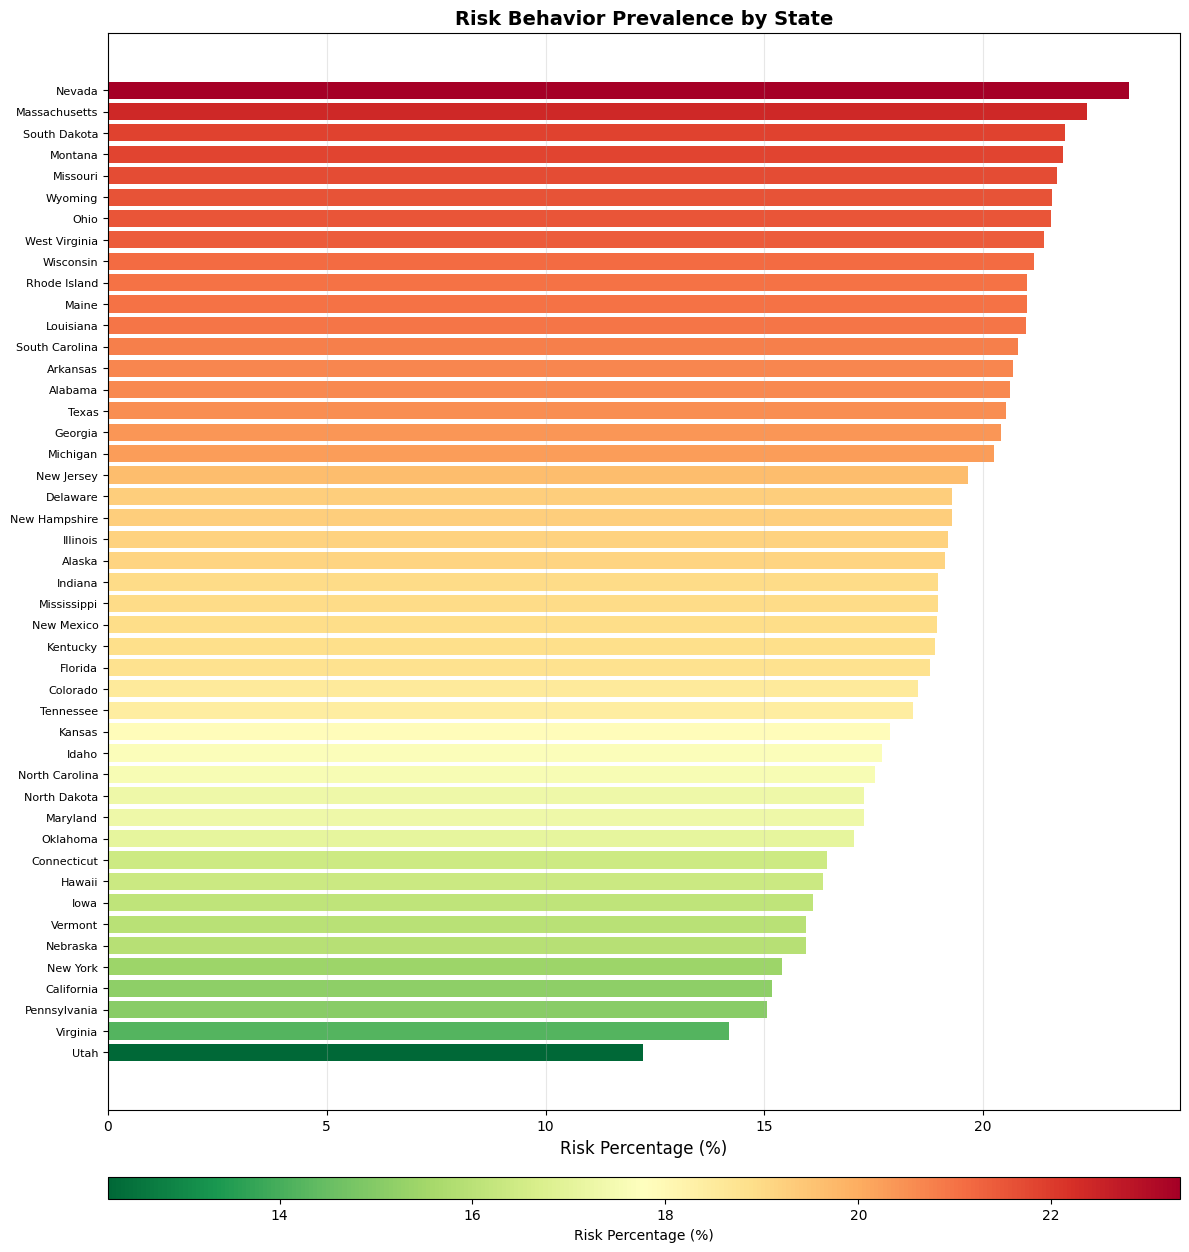

In [22]:
# Risk Behaviour Prevalence by State — Static Bar Chart
try:
    norm = plt.Normalize(state_risk['Risk_Percentage'].min(), state_risk['Risk_Percentage'].max())
    cmap = plt.cm.RdYlGn_r
    state_risk_sorted = state_risk.sort_values('Risk_Percentage', ascending=True)
    colors = cmap(norm(state_risk_sorted['Risk_Percentage'].values))

    fig, ax = plt.subplots(1, 1, figsize=(12, 14))
    ax.barh(range(len(state_risk_sorted)), state_risk_sorted['Risk_Percentage'].values, color=colors)
    ax.set_yticks(range(len(state_risk_sorted)))
    ax.set_yticklabels(state_risk_sorted['State'].values, fontsize=8)
    ax.set_xlabel('Risk Percentage (%)', fontsize=12)
    ax.set_title('Risk Behavior Prevalence by State', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cbar.set_label('Risk Percentage (%)', fontsize=10)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error: {e}")

# Geographic Analysis


In [23]:
# CREATING AN ANIMATED MAP, WHICH IS INTERACTIVE ACCORDING TO THE YEARS
if 'YEAR' in df.columns:
    try:
        # Prepare animated data
        animated_data = df.groupby(['YEAR', 'LocationAbbr'])['Greater_Risk_Data_Value'].mean().reset_index()
        animated_data.columns = ['Year', 'State_Code', 'Risk_Percentage']
        animated_data['State'] = animated_data['State_Code'].map(state_names)
        animated_data = animated_data.dropna()

        # Create animated choropleth
        fig_animated = px.choropleth(
            animated_data,
            locations='State_Code',
            locationmode='USA-states',
            color='Risk_Percentage',
            animation_frame='Year',
            scope='usa',
            color_continuous_scale='RdYlGn_r',
            range_color=[animated_data['Risk_Percentage'].min(),
                         animated_data['Risk_Percentage'].max()],
            hover_name='State',
            title='<b>Youth Risk Behavior Trends Over Time</b>',
            labels={'Risk_Percentage': 'Risk Prevalence (%)'}
        )

        fig_animated.update_layout(
            title_x=0.5,
            width=1000,
            height=600
        )

        fig_animated.show()
        fig_animated.write_html("usa_risk_map_animated.html")
        print("Animated map saved as 'usa_risk_map_animated.html'")

    except Exception as e:
        print(f"Could not create animated map: {e}")
else:
    print("Year column not found, skipping animated map")

Animated map saved as 'usa_risk_map_animated.html'


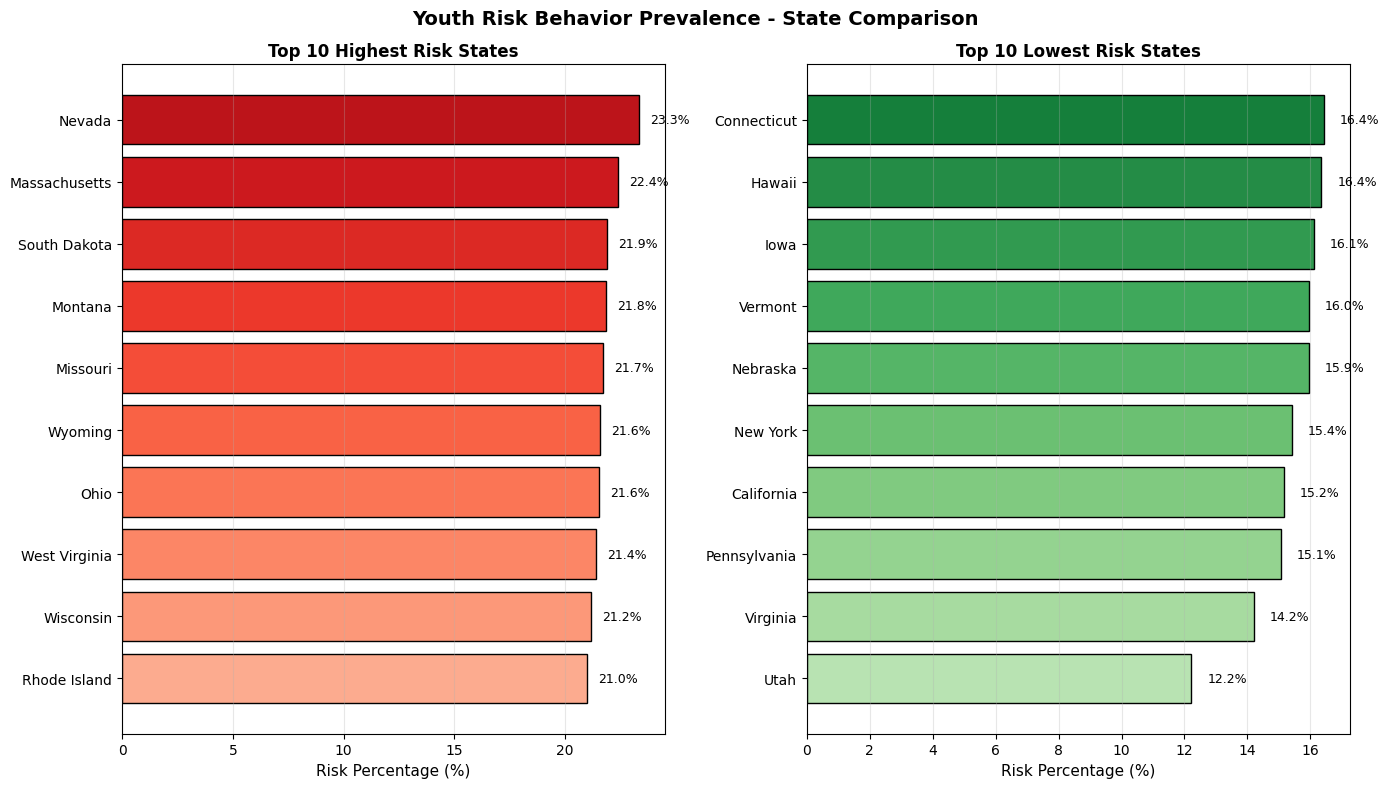


SUMMARY STATISTICS
Overall Average Risk: 18.88%
Highest Risk State: Nevada - 23.33%
Lowest Risk State: Utah - 12.22%
Standard Deviation: 2.46%


In [24]:
# CREATE TOP STATES VISUALIZATION

# Create a clear visualization of highest and lowest risk states
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Top 10 highest risk states
top_10 = state_risk.nlargest(10, 'Risk_Percentage').sort_values('Risk_Percentage')
colors_high = plt.cm.Reds(np.linspace(0.3, 0.8, len(top_10)))
ax1.barh(top_10['State'], top_10['Risk_Percentage'], color=colors_high, edgecolor='black')
ax1.set_xlabel('Risk Percentage (%)', fontsize=11)
ax1.set_title('Top 10 Highest Risk States', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top_10.iterrows()):
    ax1.text(row['Risk_Percentage'] + 0.5, i, f"{row['Risk_Percentage']:.1f}%",
             va='center', fontsize=9)

# Bottom 10 lowest risk states
bottom_10 = state_risk.nsmallest(10, 'Risk_Percentage').sort_values('Risk_Percentage')
colors_low = plt.cm.Greens(np.linspace(0.3, 0.8, len(bottom_10)))
ax2.barh(bottom_10['State'], bottom_10['Risk_Percentage'], color=colors_low, edgecolor='black')
ax2.set_xlabel('Risk Percentage (%)', fontsize=11)
ax2.set_title('Top 10 Lowest Risk States', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(bottom_10.iterrows()):
    ax2.text(row['Risk_Percentage'] + 0.5, i, f"{row['Risk_Percentage']:.1f}%",
             va='center', fontsize=9)

plt.suptitle('Youth Risk Behavior Prevalence - State Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Overall Average Risk: {state_risk['Risk_Percentage'].mean():.2f}%")
print(f"Highest Risk State: {state_risk.loc[state_risk['Risk_Percentage'].idxmax(), 'State']} - {state_risk['Risk_Percentage'].max():.2f}%")
print(f"Lowest Risk State: {state_risk.loc[state_risk['Risk_Percentage'].idxmin(), 'State']} - {state_risk['Risk_Percentage'].min():.2f}%")
print(f"Standard Deviation: {state_risk['Risk_Percentage'].std():.2f}%")

In [25]:
# DOWNLOAD MAPS

print("="*60)
print("DOWNLOAD MAP FILES")
print("="*60)

import os

# List generated files
html_files = [f for f in os.listdir() if f.endswith('.html')]
png_files = [f for f in os.listdir() if f.endswith('.png')]

if html_files:
    print("\nGenerated HTML maps:")
    for f in html_files:
        print(f"  - {f}")

    print("\nTo download a file, uncomment and run:")
    # files.download('usa_risk_map_plotly.html')

if png_files:
    print("\nGenerated PNG images:")
    for f in png_files:
        print(f"  - {f}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

DOWNLOAD MAP FILES

Generated HTML maps:
  - usa_risk_map_animated.html
  - usa_risk_map_plotly.html

To download a file, uncomment and run:

Generated PNG images:
  - grade_analysis.png
  - correlation_heatmap.png
  - column_distributions.png
  - sex_analysis.png

ANALYSIS COMPLETE!


# Correlation Analysis

In [26]:
# Correlation Matrix Function

def plotCorrelationMatrix(df, graphWidth, name='Dataset'):
    filename = name
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()


Top 10 Highest Risk Behaviors:
ShortQuestionText
Ever alcohol use                       68.486526
Source of alcohol                      38.273683
Ever marijuana use                     37.660805
Current alcohol use                    37.079745
Illegal drugs at school                26.401464
Initiation of alcohol use              23.418544
Current marijuana use                  20.449257
Ever prescription pain medicine use    12.890326
Ever inhalant use                      11.004770
Current binge drinking                 10.828664

Bottom 10 Lowest Risk Behaviors:
ShortQuestionText
Initiation of marijuana use     9.028088
Ever hallucinogenic drug use    7.643622
Ever synthetic marijuana use    7.590880
Ever ecstasy use                6.287210
Ever cocaine use                6.220624
Ever methamphetamine use        4.800480
Ever steroid use                3.715201
Largest number of drinks        3.352310
Ever heroin use                 2.956839
Illegal injected drug use       2.53927

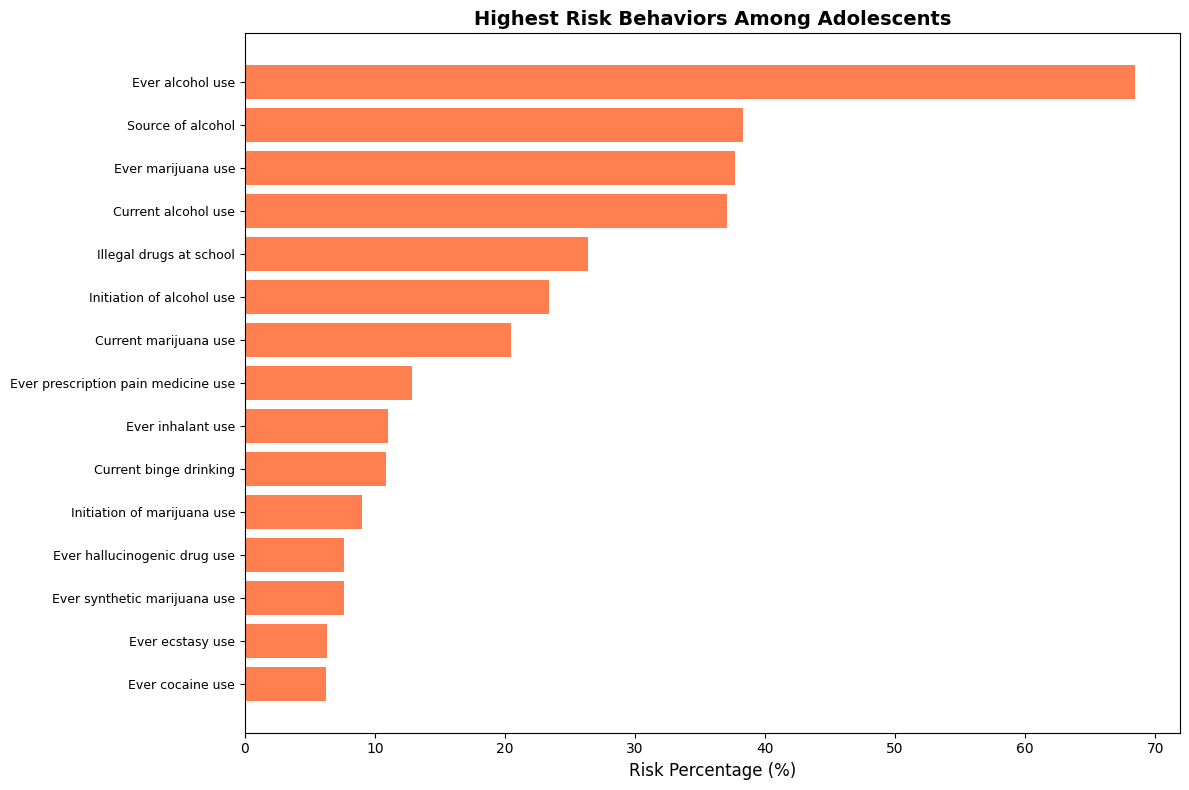

In [27]:
# Behavioural Analysis

# Create pivot table for correlation
if 'ShortQuestionText' in df.columns and 'Topic' in df.columns:
    # Get average risk per behavior
    behavior_risk = df.groupby('ShortQuestionText')['Greater_Risk_Data_Value'].mean().sort_values(ascending=False)

    print("\nTop 10 Highest Risk Behaviors:")
    print(behavior_risk.head(10).to_string())

    print("\nBottom 10 Lowest Risk Behaviors:")
    print(behavior_risk.tail(10).to_string())

    # Plot top behaviors
    plt.figure(figsize=(12, 8))
    top_behaviors = behavior_risk.head(15)
    plt.barh(range(len(top_behaviors)), top_behaviors.values, color='coral')
    plt.yticks(range(len(top_behaviors)), top_behaviors.index, fontsize=9)
    plt.xlabel('Risk Percentage (%)', fontsize=12)
    plt.title('Highest Risk Behaviors Among Adolescents', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('top_behaviors.png', dpi=300, bbox_inches='tight')
    plt.show()

# Correlation between different risk categories
# Create a pivot for correlation matrix
risk_pivot = df.pivot_table(
    values='Greater_Risk_Data_Value',
    index=['YEAR', 'LocationAbbr'],
    columns='Topic',
    aggfunc='mean'
).dropna(axis=1, how='all')

# Calculate correlation matrix
if len(risk_pivot.columns) > 1:
    corr_matrix = risk_pivot.corr()

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title('Correlation Between Different Risk Behavior Categories', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Find strongest correlations
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              corr_matrix.iloc[i, j]))

    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    print("\nStrongest Correlations Between Risk Behaviors:")
    for pair in corr_pairs[:10]:
        print(f"  {pair[0]} & {pair[1]}: {pair[2]:.3f}")

#Machine Learning & Predictive Modelling

# Predictive Analysis

Predictive data analysis involves building models to predict future outcomes based on historical data. It focuses on 'what could happen in the future'.

## Common Algorithms:

* Linear regression
* Decision trees
* Random forests
* Support vector machines
* Neural networks

In [28]:
# Machine Learning Libraries
print("All ML libraries loaded from Cell 2 — ready.")

All ML libraries loaded from Cell 2 — ready.


In [29]:
# Feature Selection
# Removed Greater_Risk_Low_Confidence_Limit and Greater_Risk_High_Confidence_Limit
# because they are statistically derived FROM the target variable — using them
# causes data leakage (artificially perfect scores).
# Removed Lesser_Risk_Data_Value for the same reason (it mirrors the target).
# Using only genuine demographic, geographic and categorical predictors.

selected_cols = [
    'YEAR',          # Temporal trend
    'LocationAbbr',  # State — geographic predictor
    'Topic',         # Type of risk behaviour (Alcohol, Tobacco, etc.)
    'Subtopic',      # Sub-category of risk behaviour
    'Sex',           # Demographic
    'Race',          # Demographic
    'Grade',         # School grade
    'Data_Value_Type', # How the value was measured
    # Target
    'Greater_Risk_Data_Value'
]

# Only keep columns that actually exist
selected_cols = [c for c in selected_cols if c in df.columns]
print(f"Features being used: {[c for c in selected_cols if c != 'Greater_Risk_Data_Value']}")

ml_df = df[selected_cols].copy()

# Convert all category columns to string for the pipeline
for col in ml_df.select_dtypes(include='category').columns:
    ml_df[col] = ml_df[col].astype(str)

# Drop rows where target is missing
ml_df = ml_df.dropna(subset=['Greater_Risk_Data_Value'])

print(f"\nML dataset shape: {ml_df.shape}")
print(f"\nTarget variable stats:")
print(ml_df['Greater_Risk_Data_Value'].describe())
ml_df.head()

Features being used: ['YEAR', 'LocationAbbr', 'Topic', 'Subtopic', 'Sex', 'Race', 'Grade', 'Data_Value_Type']

ML dataset shape: (353522, 9)

Target variable stats:
count    353522.000000
mean         18.761156
std          19.030676
min           0.000000
25%           4.293325
50%          11.353150
75%          28.007375
max          97.032900
Name: Greater_Risk_Data_Value, dtype: float64


,YEAR,LocationAbbr,Topic,Subtopic,Sex,Race,Grade,Data_Value_Type,Greater_Risk_Data_Value
2,1995,HO,Alcohol and Other Drug Use,Other Drug Use,Female,Hispanic or Latino,Total,Percentage,4.9938
8,1997,HO,Alcohol and Other Drug Use,Alcohol Use,Total,Black or African American,Total,Percentage,40.8283
13,1993,NV,Alcohol and Other Drug Use,Alcohol Use,Female,White,10th,Percentage,39.9928
15,2017,PA,Alcohol and Other Drug Use,Other Drug Use,Male,Asian,Total,Percentage,0.4087
17,2007,SF,Alcohol and Other Drug Use,Other Drug Use,Female,Multiple Race,Total,Percentage,0.0000


In [30]:
# Regression Target
X_reg = ml_df.drop('Greater_Risk_Data_Value', axis=1)
y_reg  = ml_df['Greater_Risk_Data_Value']
print(f"Features : {X_reg.shape[1]} columns")
print(f"Samples  : {X_reg.shape[0]:,} rows")
print(f"Target   : {y_reg.min():.1f}% — {y_reg.max():.1f}%  (mean {y_reg.mean():.1f}%)")

Features : 8 columns
Samples  : 353,522 rows
Target   : 0.0% — 97.0%  (mean 18.8%)


In [31]:
# Classification Target — High Risk Label (above median)
median_value = ml_df['Greater_Risk_Data_Value'].median()
print(f"Median risk threshold: {median_value:.2f}%")

ml_df['High_Risk_Label'] = (ml_df['Greater_Risk_Data_Value'] > median_value).astype(int)

X_clf = ml_df.drop(['Greater_Risk_Data_Value', 'High_Risk_Label'], axis=1)
y_clf = ml_df['High_Risk_Label']

counts = y_clf.value_counts()
print(f"Low Risk  (0): {counts[0]:,} rows ({counts[0]/len(y_clf)*100:.1f}%)")
print(f"High Risk (1): {counts[1]:,} rows ({counts[1]/len(y_clf)*100:.1f}%)")

Median risk threshold: 11.35%
Low Risk  (0): 176,761 rows (50.0%)
High Risk (1): 176,761 rows (50.0%)


In [32]:
# Preprocessing Pipeline

def build_preprocessor(X):
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_cols   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
    return preprocessor

print("Preprocessor function ready.")
print(f"Numerical features  : {X_reg.select_dtypes(include=['int64','float64']).columns.tolist()}")
print(f"Categorical features: {X_reg.select_dtypes(include=['object','category']).columns.tolist()}")

Preprocessor function ready.
Numerical features  : ['YEAR']
Categorical features: ['LocationAbbr', 'Topic', 'Subtopic', 'Sex', 'Race', 'Grade', 'Data_Value_Type']


In [33]:
# Train-Test Split
# Dataset has 353k+ valid rows — using a 100k sample for faster training
# while still being statistically representative.

from sklearn.utils import resample

ml_df_sample = resample(ml_df, n_samples=100000, random_state=42)

X_reg = ml_df_sample.drop(['Greater_Risk_Data_Value', 'High_Risk_Label'], axis=1, errors='ignore')
y_reg = ml_df_sample['Greater_Risk_Data_Value']

X_clf = ml_df_sample.drop(['Greater_Risk_Data_Value', 'High_Risk_Label'], axis=1, errors='ignore')
y_clf = ml_df_sample['High_Risk_Label']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Regression   — Train: {X_train_reg.shape[0]:,}  Test: {X_test_reg.shape[0]:,}")
print(f"Classification — Train: {X_train_clf.shape[0]:,}  Test: {X_test_clf.shape[0]:,}")

Regression   — Train: 80,000  Test: 20,000
Classification — Train: 80,000  Test: 20,000


Regression Model Comparison:


,R²,RMSE,MAE
CatBoost,0.4641,14.1078,10.9383
XGBoost,0.4605,14.1549,10.9602
Gradient Boosting,0.4428,14.3855,11.1685
Random Forest,0.3267,15.8131,11.6839


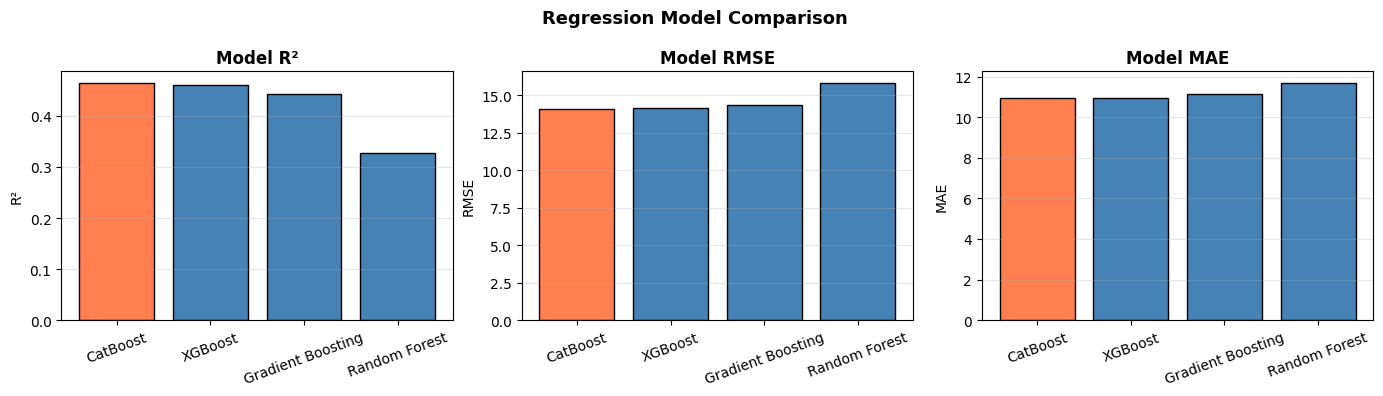

In [34]:
# Regression Models — Comparison

reg_models = {
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1),
    'CatBoost':          CatBoostRegressor(iterations=100, verbose=0, random_state=42)
}

reg_results = {}
for name, model in reg_models.items():
    pipe = Pipeline([
        ('preprocessor', build_preprocessor(X_reg)),
        ('model', model)
    ])
    pipe.fit(X_train_reg, y_train_reg)
    preds = pipe.predict(X_test_reg)

    reg_results[name] = {
        'R²':   round(r2_score(y_test_reg, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, preds)), 4),
        'MAE':  round(mean_absolute_error(y_test_reg, preds), 4)
    }

results_df = pd.DataFrame(reg_results).T.sort_values('R²', ascending=False)
print("Regression Model Comparison:")
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    vals = results_df[metric]
    highlight = vals.idxmax() if metric == 'R²' else vals.idxmin()
    colors = ['coral' if i == highlight else 'steelblue' for i in vals.index]
    ax.bar(vals.index, vals.values, color=colors, edgecolor='black')
    ax.set_title(f'Model {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Regression Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Classification Model Comparison:


,Accuracy,AUC-ROC
XGBoost,0.7195,0.7813
CatBoost,0.7175,0.7798
Gradient Boosting,0.7114,0.7761
Random Forest,0.6794,0.7487


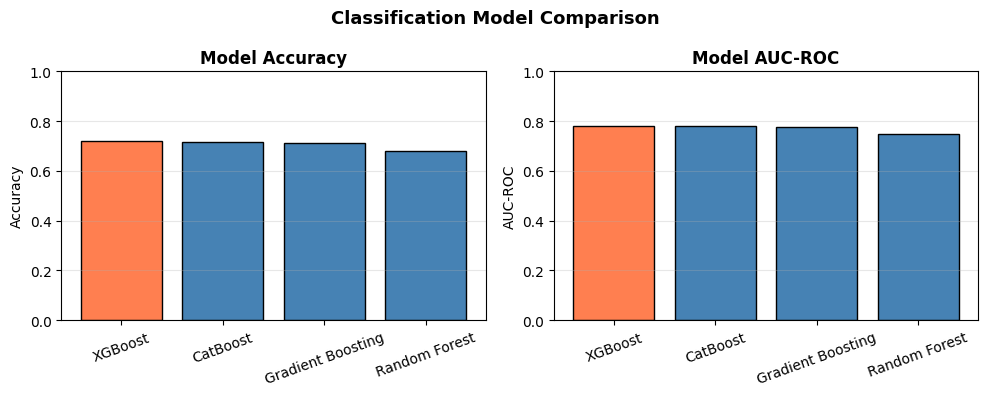

In [35]:
# Classification Models — Comparison

clf_models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':           XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, verbosity=0, n_jobs=-1),
    'CatBoost':          CatBoostClassifier(iterations=100, verbose=0, random_state=42)
}

clf_results = {}
for name, model in clf_models.items():
    pipe = Pipeline([
        ('preprocessor', build_preprocessor(X_clf)),
        ('model', model)
    ])
    pipe.fit(X_train_clf, y_train_clf)
    preds = pipe.predict(X_test_clf)
    probs = pipe.predict_proba(X_test_clf)[:, 1]

    clf_results[name] = {
        'Accuracy': round(accuracy_score(y_test_clf, preds), 4),
        'AUC-ROC':  round(roc_auc_score(y_test_clf, probs), 4)
    }

clf_df = pd.DataFrame(clf_results).T.sort_values('AUC-ROC', ascending=False)
print("Classification Model Comparison:")
display(clf_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['Accuracy', 'AUC-ROC']):
    vals = clf_df[metric]
    colors = ['coral' if i == vals.idxmax() else 'steelblue' for i in vals.index]
    ax.bar(vals.index, vals.values, color=colors, edgecolor='black')
    ax.set_title(f'Model {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Classification Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# Hyperparameter Tuning — XGBoost Regressor (GridSearchCV)

param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample':     [0.8, 1.0]
}

xgb_pipe = Pipeline([
    ('preprocessor', build_preprocessor(X_reg)),
    ('model', XGBRegressor(random_state=42, verbosity=0, n_jobs=-1))
])

grid_search = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_reg, y_train_reg)
best_regressor = grid_search.best_estimator_
best_preds     = best_regressor.predict(X_test_reg)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")
print(f"Test R²         : {r2_score(y_test_reg, best_preds):.4f}")
print(f"Test RMSE       : {np.sqrt(mean_squared_error(y_test_reg, best_preds)):.4f}")
print(f"Test MAE        : {mean_absolute_error(y_test_reg, best_preds):.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters : {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV R²      : 0.4573
Test R²         : 0.4635
Test RMSE       : 14.1154
Test MAE        : 10.9377


Cross-Validation R² Scores: [0.4537 0.4622 0.4609 0.4643 0.4629]
Mean R²  : 0.4608
Std Dev  : 0.0037


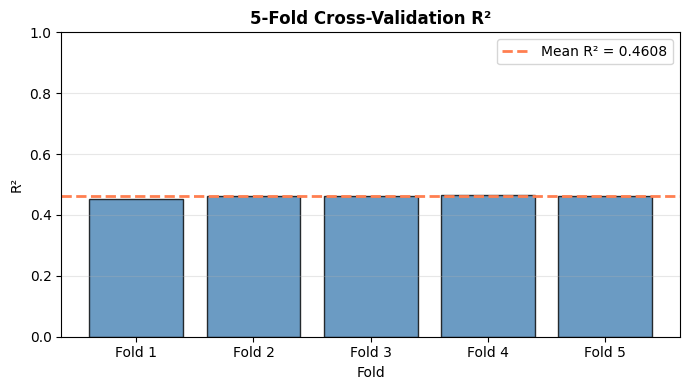

In [37]:
# Cross-Validation of Best Regressor (5-Fold)
cv_scores = cross_val_score(
    best_regressor, X_reg, y_reg, cv=5, scoring='r2', n_jobs=-1
)

print("Cross-Validation R² Scores:", np.round(cv_scores, 4))
print(f"Mean R²  : {cv_scores.mean():.4f}")
print(f"Std Dev  : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar([f'Fold {i+1}' for i in range(5)], cv_scores,
        color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean(), color='coral', linestyle='--', linewidth=2,
            label=f'Mean R² = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R²')
plt.title('5-Fold Cross-Validation R²', fontweight='bold')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

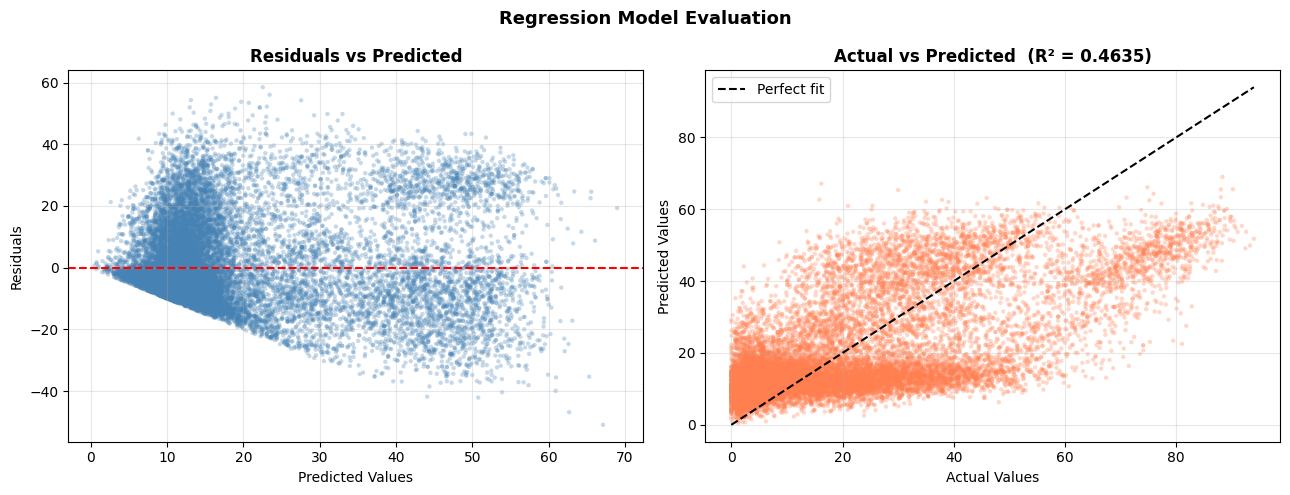

In [38]:
# Residual Plot — Regression Evaluation
y_pred_reg = best_regressor.predict(X_test_reg)
residuals  = y_test_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_reg, residuals, alpha=0.3, color='steelblue', edgecolors='none', s=10)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_reg, y_pred_reg, alpha=0.3, color='coral', edgecolors='none', s=10)
min_val, max_val = y_test_reg.min(), y_test_reg.max()
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title(f'Actual vs Predicted  (R² = {r2_score(y_test_reg, y_pred_reg):.4f})',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Regression Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.65      0.91      0.76      9959
   High Risk       0.85      0.51      0.64     10041

    accuracy                           0.71     20000
   macro avg       0.75      0.71      0.70     20000
weighted avg       0.75      0.71      0.70     20000



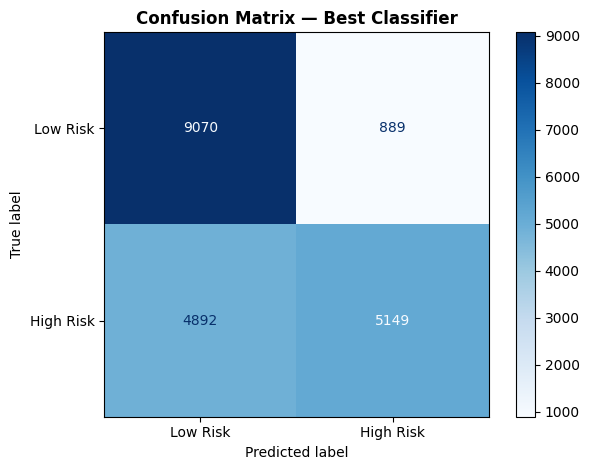

In [39]:
# Best Classifier — Random Forest with Tuned Parameters
best_classifier = Pipeline([
    ('preprocessor', build_preprocessor(X_clf)),
    ('model', RandomForestClassifier(
        n_estimators=200, max_depth=20,
        min_samples_split=5, random_state=42, n_jobs=-1
    ))
])

best_classifier.fit(X_train_clf, y_train_clf)
y_pred_clf = best_classifier.predict(X_test_clf)

print("Classification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Low Risk', 'High Risk']))

cm   = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Best Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

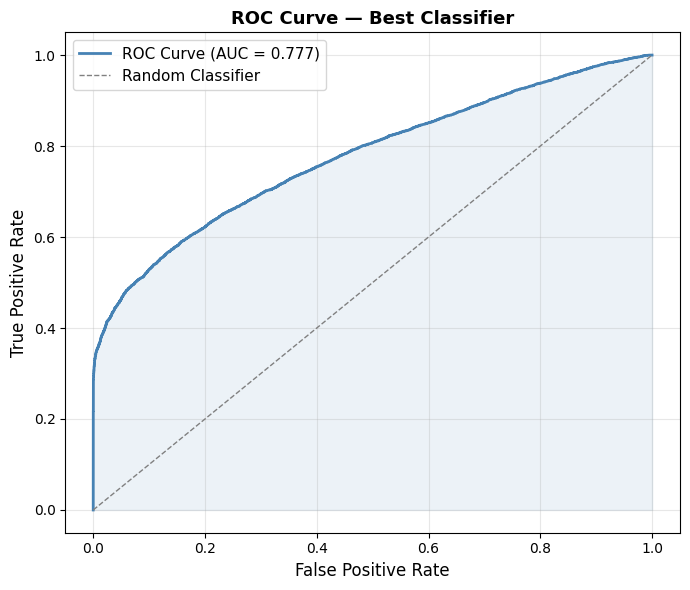

AUC-ROC: 0.7766
AUC > 0.9 = Excellent  |  > 0.8 = Good  |  > 0.7 = Fair  |  < 0.7 = Poor


In [40]:
# ROC Curve — Classification Evaluation
y_probs   = best_classifier.predict_proba(X_test_clf)[:, 1]
fpr, tpr, _ = roc_curve(y_test_clf, y_probs)
auc_score = roc_auc_score(y_test_clf, y_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Best Classifier', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {auc_score:.4f}")
print("AUC > 0.9 = Excellent  |  > 0.8 = Good  |  > 0.7 = Fair  |  < 0.7 = Poor")

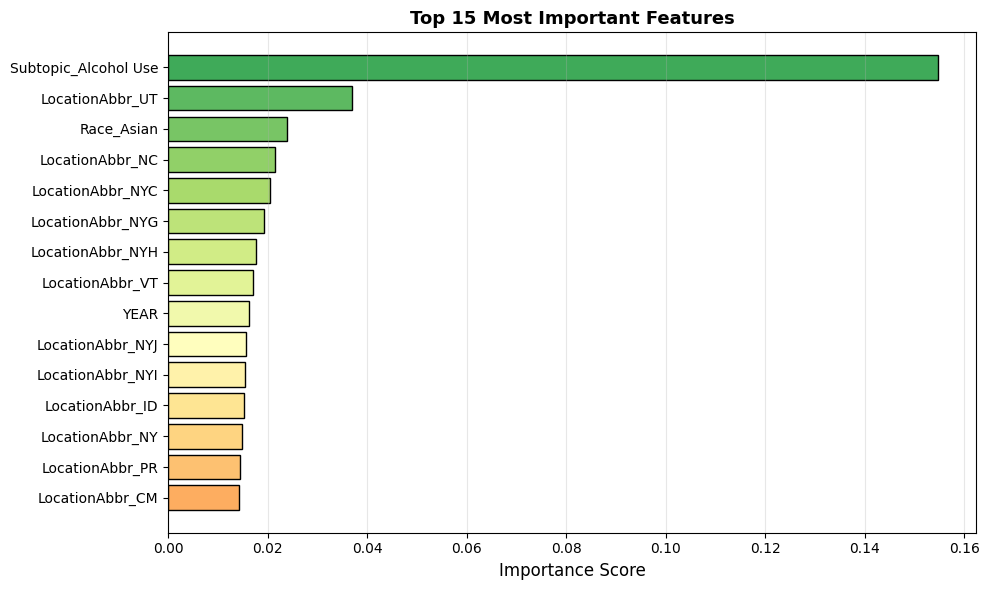


Top 10 features:


,Feature,Importance
93,Subtopic_Alcohol Use,0.154667
84,LocationAbbr_UT,0.036867
99,Race_Asian,0.023956
49,LocationAbbr_NC,0.021420
58,LocationAbbr_NYC,0.020392
59,LocationAbbr_NYG,0.019226
60,LocationAbbr_NYH,0.017675
86,LocationAbbr_VT,0.017071
0,YEAR,0.016324
62,LocationAbbr_NYJ,0.015650


In [41]:
# Feature Importance — Top 15 Predictors
feature_names = best_regressor.named_steps['preprocessor'].get_feature_names_out()
importances   = best_regressor.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

feat_imp['Feature'] = feat_imp['Feature'].str.replace(r'^(num__|cat__)', '', regex=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, len(feat_imp)))[::-1]
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
         color=colors[::-1], edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
display(feat_imp.head(10))

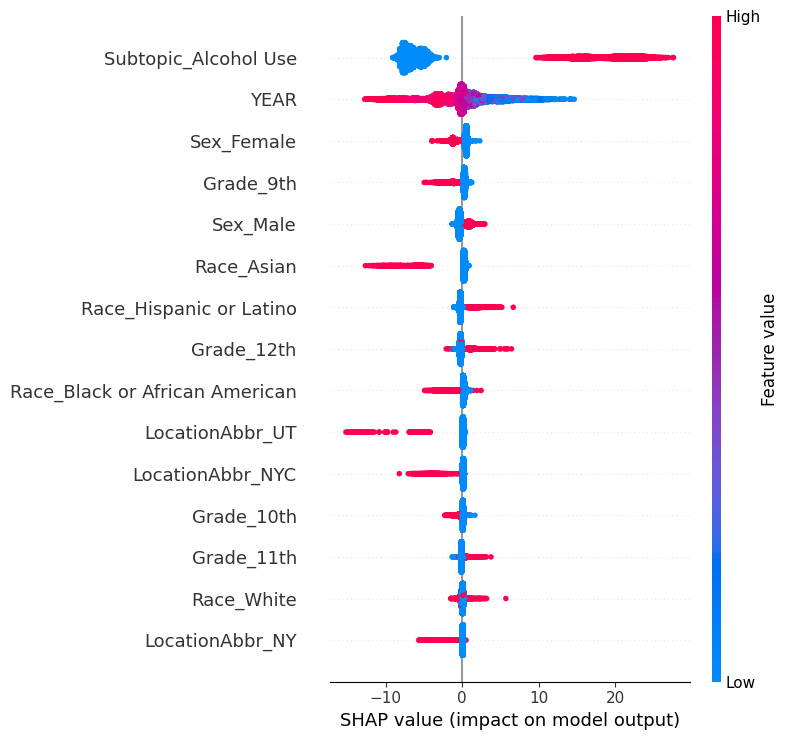

In [42]:
# SHAP Analysis — Model Interpretability
X_processed = best_regressor.named_steps['preprocessor'].transform(X_test_reg)
feature_names_clean = [
    name.replace('num__', '').replace('cat__', '')
    for name in best_regressor.named_steps['preprocessor'].get_feature_names_out()
]

explainer   = shap.TreeExplainer(best_regressor.named_steps['model'])
shap_values = explainer.shap_values(X_processed)

shap.summary_plot(shap_values, X_processed,
                  feature_names=feature_names_clean, max_display=15)

In [43]:
# Modelling Results Summary
reg_r2   = r2_score(y_test_reg, best_regressor.predict(X_test_reg))
reg_rmse = np.sqrt(mean_squared_error(y_test_reg, best_regressor.predict(X_test_reg)))
clf_acc  = accuracy_score(y_test_clf, best_classifier.predict(X_test_clf))
clf_auc  = roc_auc_score(y_test_clf, best_classifier.predict_proba(X_test_clf)[:, 1])

print("=" * 55)
print("  MODELLING RESULTS SUMMARY")
print("=" * 55)
print(f"\n  REGRESSION  (predicts exact risk prevalence %)")
print(f"    Best Model : XGBoost (tuned)")
print(f"    R²         : {reg_r2:.4f}")
print(f"    RMSE       : {reg_rmse:.4f}")
print(f"\n  CLASSIFICATION  (predicts High vs Low risk group)")
print(f"    Best Model : Random Forest (tuned)")
print(f"    Accuracy   : {clf_acc:.4f}")
print(f"    AUC-ROC    : {clf_auc:.4f}")
print("=" * 55)

  MODELLING RESULTS SUMMARY

  REGRESSION  (predicts exact risk prevalence %)
    Best Model : XGBoost (tuned)
    R²         : 0.4635
    RMSE       : 14.1154

  CLASSIFICATION  (predicts High vs Low risk group)
    Best Model : Random Forest (tuned)
    Accuracy   : 0.7109
    AUC-ROC    : 0.7766
